# 03. Peter: setores econômicos, estados e correlações
**João Pedro Amorim (Peter) · Ciência de Dados / UNIFOR · Sudeste, 2020**

Objetivo: descrever diferenças econômicas e populacionais entre ES, MG, RJ e SP, analisar a composição do valor adicionado (VA) e as relações entre variáveis municipais. Esta seção usa exclusivamente a base preparada pelo grupo. O recorte regional não permite generalizar os resultados para todo o Brasil.

## 1. Fontes, conceitos e decisões
- PIB e população: 2020, conforme os metadados do projeto. Valores monetários já estão em **reais correntes**, sem nova multiplicação por mil.
- Unidade de análise: município. Agregação estadual: soma dos valores municipais. PIB per capita estadual = soma do PIB / soma da população.
- Serviços: exclui administração, defesa, educação e saúde públicas e seguridade social (SIDRA 5938, variável 6575). Administração Pública corresponde a essas atividades (variável 525).
- Participação setorial = 100 × VA do setor / soma dos quatro VAs. O denominador é o **VA total**, não o PIB. Impostos líquidos de subsídios ficam fora da composição setorial.
- As participações estaduais usam somas, não a média simples dos percentuais municipais.
- Correlação de Pearson nos valores originais e em log10, complementada por Spearman entre PIB e população. Nenhuma delas demonstra causalidade.
- A edição da DTB é desconhecida. O ano de 2020 é um recorte específico, e PIB por habitante não mede renda pessoal nem distribuição de renda.

Fontes: [SIDRA 5938](https://sidra.ibge.gov.br/tabela/5938), [metadados oficiais da tabela](https://servicodados.ibge.gov.br/api/v3/agregados/5938/metadados), [SIDRA 6579](https://sidra.ibge.gov.br/tabela/6579), `data/processed/metadados.json` e `docs/dicionario_dados.md`. A resposta da API consultada em 21/09/2026 foi arquivada em `outputs/peter/fontes/` para registrar os conceitos, sem substituir os dados de 2020.

In [1]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

# Encontra a raiz executando da raiz, da pasta de contribuições ou do notebook integrado.
peter_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / 'data/processed/sudeste_municipios.parquet').exists()), None)
if peter_root is None:
    raise FileNotFoundError('Execute dentro do repositório com a base Parquet preparada por Luma.')
peter_base = peter_root / 'data/processed/sudeste_municipios.parquet'
peter_df = pd.read_parquet(peter_base).copy()
peter_out = peter_root / 'outputs/peter'
peter_fig = peter_root / 'outputs/figures'
peter_out.mkdir(parents=True, exist_ok=True)
peter_fig.mkdir(parents=True, exist_ok=True)
(peter_out / 'tabelas').mkdir(exist_ok=True)
peter_ufs = ['ES', 'MG', 'RJ', 'SP']
peter_setores = {
 'va_agropecuaria_reais': 'Agropecuária',
 'va_industria_reais': 'Indústria',
 'va_servicos_reais': 'Serviços¹',
 'va_administracao_publica_reais': 'Administração pública²'
}
peter_vas = list(peter_setores)
peter_vars = ['pib_total_reais', 'populacao', 'pib_per_capita_reais'] + peter_vas
peter_labels = ['PIB', 'População', 'PIB per capita', 'Agropecuária', 'Indústria', 'Serviços¹', 'Admin. pública²']
peter_cores = ['#287A49', '#CF8734', '#146D7A', '#873D5F']
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110, 'axes.titleweight': 'bold'})
def peter_br(x, casas=1):
    return f'{x:,.{casas}f}'.replace(',', '_').replace('.', ',').replace('_', '.')
def peter_salvar(fig, nome):
    fig.savefig(peter_fig / f'peter_{nome}.png', dpi=200, bbox_inches='tight')
    fig.savefig(peter_fig / f'peter_{nome}.svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)
def peter_csv(tab, nome):
    tab.to_csv(peter_out / 'tabelas' / f'{nome}.csv', encoding='utf-8', index=True)
print('SHA-256 da base:', hashlib.sha256(peter_base.read_bytes()).hexdigest())

SHA-256 da base: 26975160e61731a3ec468342e47f16cfdd42a53e2eed3c325d4ce1ffffd9b402


## 2. Conferência da base
As verificações impedem somas silenciosas com dados faltantes, duplicatas ou anos misturados. Valores negativos não são corrigidos automaticamente. Para o log, usamos somente linhas estritamente positivas e informamos as exclusões.

A identidade contábil esperada é PIB ≈ soma dos VAs + impostos líquidos de subsídios. Os seis termos foram originalmente arredondados em mil reais. Uma tolerância de R$ 3.000 por município cobre até R$ 500 de arredondamento por termo.

In [2]:
assert set(peter_df.uf) == set(peter_ufs), 'Recorte diferente do Sudeste'
assert set(peter_df.ano) == {2020}, 'Ano diferente do contrato'
assert not peter_df.duplicated(['codigo_municipio','ano']).any(), 'Chaves duplicadas'
peter_num = peter_vars + ['impostos_reais']
assert not peter_df[peter_num].isna().any().any(), 'Há valores ausentes; revisar antes de agregar'
assert np.isfinite(peter_df[peter_num].to_numpy(dtype=float)).all(), 'Há valores não finitos'
assert (peter_df.populacao > 0).all() and (peter_df.pib_total_reais > 0).all()
assert (peter_df[peter_vas] >= 0).all().all(), 'VA negativo exige revisão'
assert np.allclose(peter_df.pib_per_capita_reais,
                   peter_df.pib_total_reais / peter_df.populacao), 'PIB per capita inconsistente'
peter_df['va_total_reais'] = peter_df[peter_vas].sum(axis=1)
assert (peter_df.va_total_reais > 0).all()
peter_residuo = peter_df.pib_total_reais - peter_df.va_total_reais - peter_df.impostos_reais
assert peter_residuo.abs().max() <= 3000, 'Identidade contábil incompatível; revisar setores'
peter_cobertura = peter_df.groupby('uf').size().rename('municipios').reindex(peter_ufs)
display(peter_cobertura.to_frame())
print('Municípios:', len(peter_df))
print('Ausências nas variáveis analisadas:', int(peter_df[peter_num].isna().sum().sum()))
print('Maior resíduo absoluto (R$):', peter_residuo.abs().max())
peter_csv(peter_cobertura.to_frame(), 'cobertura')
peter_csv(peter_df[['codigo_municipio','municipio','uf']].assign(residuo_reais=peter_residuo), 'conciliacao_contabil')

Municípios: 1668
Ausências nas variáveis analisadas: 0
Maior resíduo absoluto (R$): 2000.0


,municipios
uf,
ES,78
MG,853
RJ,92
SP,645


## 3. Comparação entre estados
PIB total representa o volume produzido, população representa o número de residentes e PIB per capita expressa produção por habitante. Comparamos essas medidas separadamente para evitar confundir tamanho econômico e valor por pessoa.

,pib_total_reais,populacao,pib_per_capita_reais,participacao_pib_sudeste_pct,participacao_pop_sudeste_pct
uf,,,,,
ES,138445925000.0,4064052,34065.98,3.5,4.57
MG,682786114000.0,21292666,32066.73,17.27,23.92
RJ,753823710000.0,17366189,43407.55,19.07,19.51
SP,2377638983000.0,46289333,51364.73,60.15,52.0


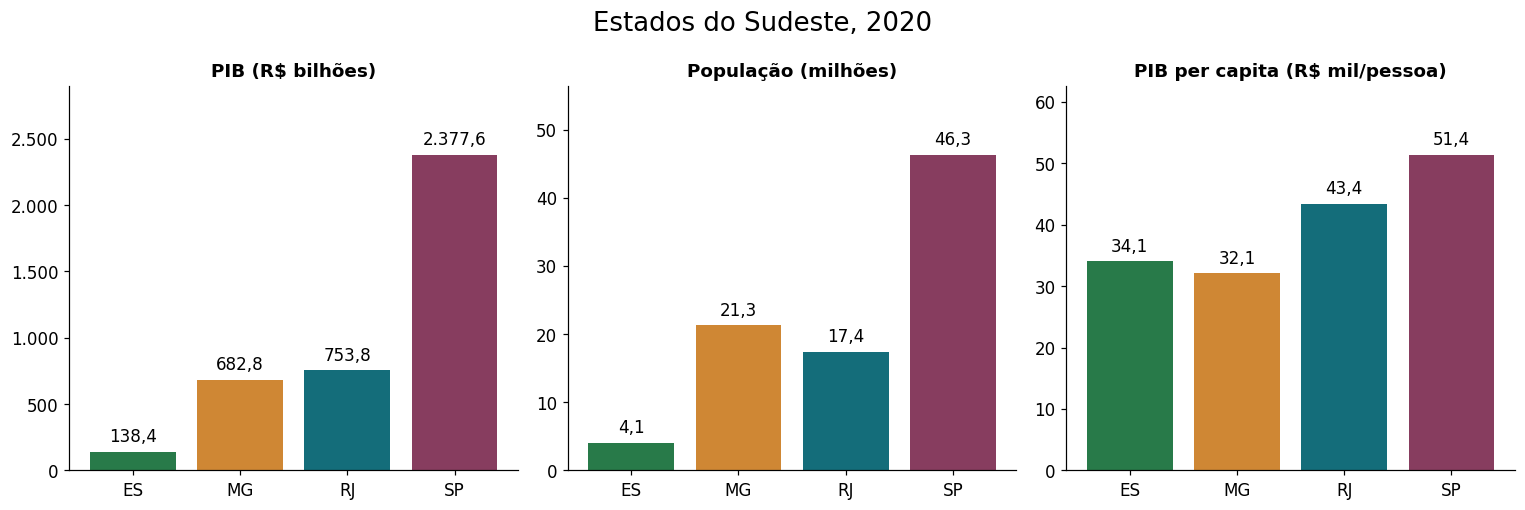

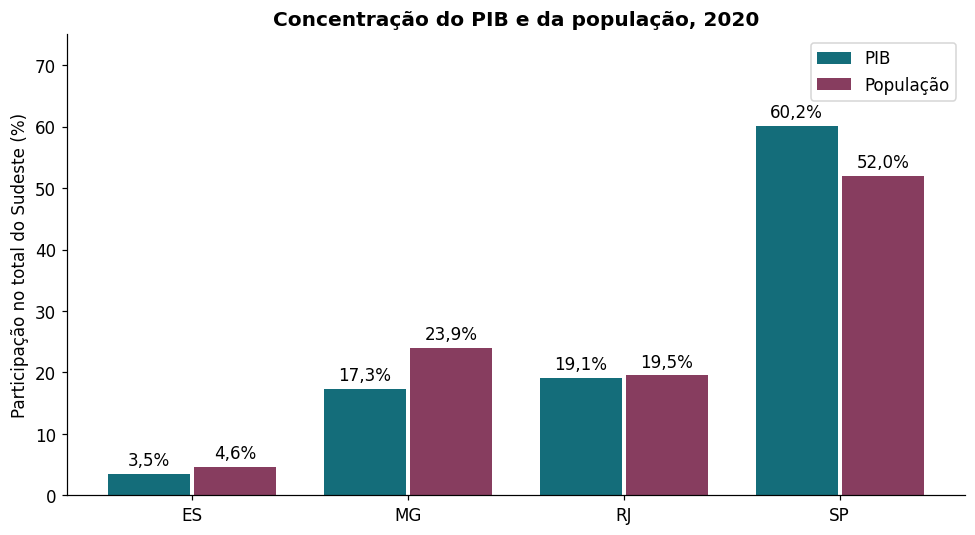

**Interpretação:** SP concentra 60,2% do PIB e 52,0% da população regional. O maior PIB per capita estadual é SP, e o menor é MG, com razão de 1,60 vez. Esses indicadores mostram disparidades territoriais de produção, sem medir diretamente a desigualdade de renda entre pessoas.

In [3]:
peter_somaveis = ['pib_total_reais','populacao','impostos_reais','va_total_reais'] + peter_vas
peter_estados = peter_df.groupby('uf')[peter_somaveis].sum().reindex(peter_ufs)
peter_estados['pib_per_capita_reais'] = peter_estados.pib_total_reais / peter_estados.populacao
peter_estados['participacao_pib_sudeste_pct'] = 100*peter_estados.pib_total_reais/peter_estados.pib_total_reais.sum()
peter_estados['participacao_pop_sudeste_pct'] = 100*peter_estados.populacao/peter_estados.populacao.sum()
peter_csv(peter_estados, 'comparacao_estados')
display(peter_estados[['pib_total_reais','populacao','pib_per_capita_reais',
                       'participacao_pib_sudeste_pct','participacao_pop_sudeste_pct']].round(2))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))
for ax, col, escala, titulo in zip(axes,
    ['pib_total_reais','populacao','pib_per_capita_reais'], [1e9,1e6,1e3],
    ['PIB (R$ bilhões)','População (milhões)','PIB per capita (R$ mil/pessoa)']):
    valores = peter_estados[col]/escala
    bars = ax.bar(peter_ufs, valores, color=peter_cores)
    ax.bar_label(bars, labels=[peter_br(x) for x in valores], padding=4)
    ax.set_ylim(0, valores.max()*1.22)
    ax.set_title(titulo, fontsize=12)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: peter_br(x,0)))
fig.suptitle('Estados do Sudeste, 2020', fontsize=17)
fig.tight_layout()
peter_salvar(fig, 'comparacao_estados')
fig, ax = plt.subplots(figsize=(9,5))
x=np.arange(4)
for deslocamento, col, label, cor in [(-.2,'participacao_pib_sudeste_pct','PIB','#146D7A'),(.2,'participacao_pop_sudeste_pct','População','#873D5F')]:
    bars=ax.bar(x+deslocamento,peter_estados[col],width=.38,label=label,color=cor)
    ax.bar_label(bars,labels=[peter_br(v)+'%' for v in peter_estados[col]],padding=3)
ax.set_xticks(x,peter_ufs); ax.set_ylim(0,75); ax.set_ylabel('Participação no total do Sudeste (%)')
ax.set_title('Concentração do PIB e da população, 2020'); ax.legend()
fig.tight_layout(); peter_salvar(fig,'participacoes_pib_populacao')
peter_sp=peter_estados.loc['SP']
peter_razao = peter_estados.pib_per_capita_reais.max()/peter_estados.pib_per_capita_reais.min()
display(Markdown(f"""**Interpretação:** SP concentra {peter_br(peter_sp.participacao_pib_sudeste_pct)}% do PIB e {peter_br(peter_sp.participacao_pop_sudeste_pct)}% da população regional. O maior PIB per capita estadual é {peter_estados.pib_per_capita_reais.idxmax()}, e o menor é {peter_estados.pib_per_capita_reais.idxmin()}, com razão de {peter_br(peter_razao,2)} vez. Esses indicadores mostram disparidades territoriais de produção, sem medir diretamente a desigualdade de renda entre pessoas."""))

## 4. Composição econômica
O VA mede a contribuição de cada atividade à produção, descontado o consumo intermediário. A soma dos quatro setores é o denominador dos percentuais abaixo.

¹ Serviços exclui o grupo público especificado pelo IBGE. ² Administração pública inclui administração, defesa, educação e saúde públicas e seguridade social. Os rótulos abreviados nos gráficos mantêm essa definição.

,va_reais,participacao_va_sudeste_pct
Agropecuária,93293371000.0,2.76
Indústria,771869950000.0,22.8
Serviços¹,2067750923000.0,61.09
Administração pública²,452009443000.0,13.35


,Agropecuária,Indústria,Serviços¹,Administração pública²
uf,,,,
ES,4.55,27.4,51.43,16.62
MG,6.65,27.62,49.09,16.63
RJ,0.56,24.07,54.62,20.74
SP,2.2,20.69,67.32,9.79


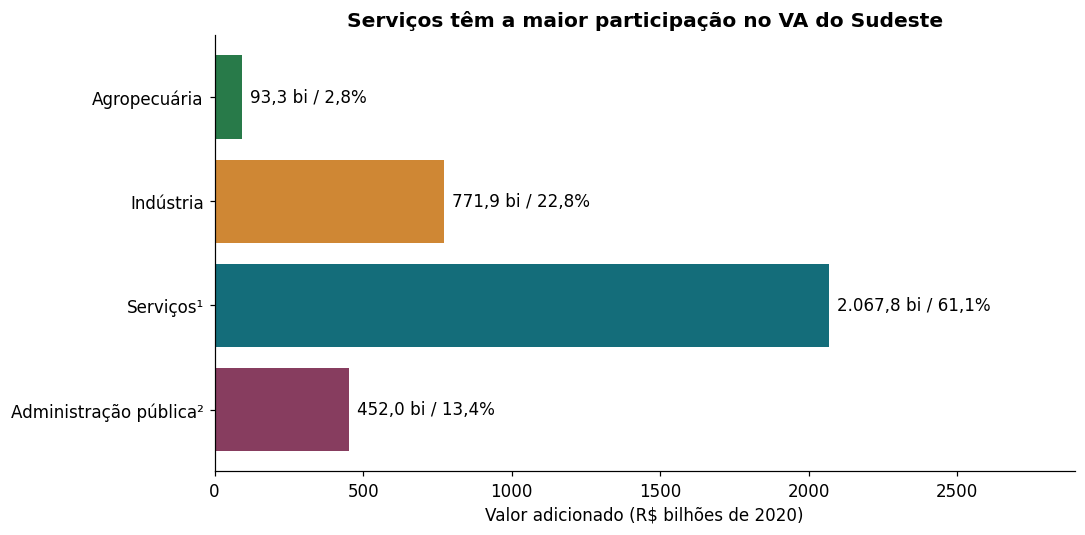

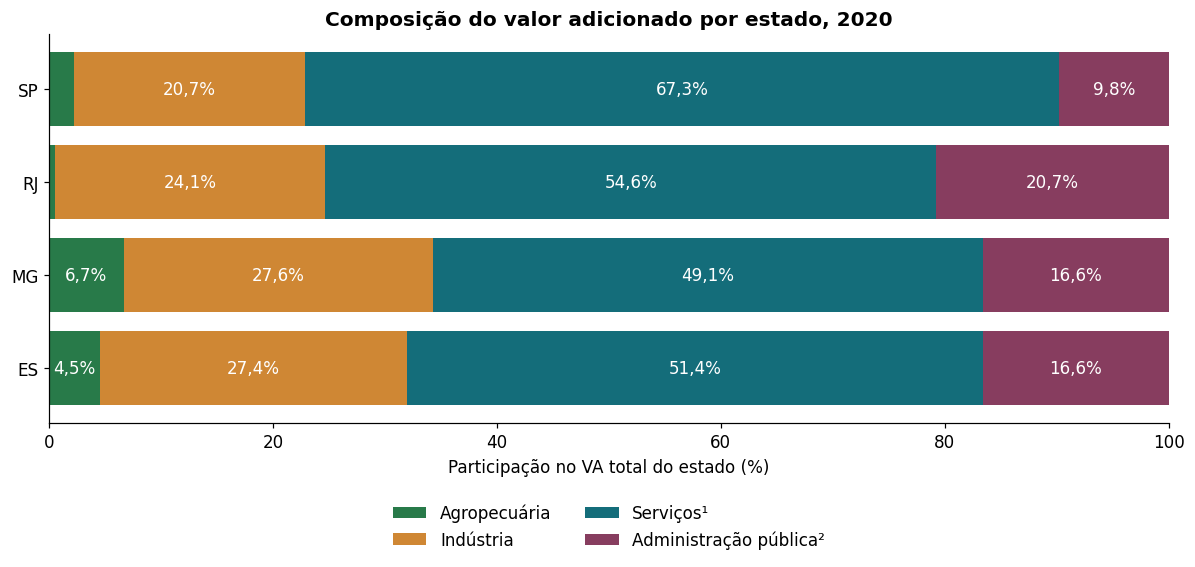

**Interpretação:** Serviços¹ responde por 61,1% do VA regional e é o maior setor em todos os quatro estados. A maior participação da Agropecuária é de MG (6,7%). A maior participação da Indústria é de MG (27,6%). Participação elevada não implica maior volume absoluto nem identifica, sozinha, a causa dessas diferenças.

In [4]:
peter_totais = peter_df[peter_vas].sum()
peter_setorial = pd.DataFrame({'va_reais':peter_totais,
    'participacao_va_sudeste_pct':100*peter_totais/peter_totais.sum()}).rename(index=peter_setores)
peter_comp = peter_estados[peter_vas].div(peter_estados.va_total_reais,axis=0)*100
assert np.allclose(peter_comp.sum(axis=1),100)
assert np.isclose(peter_setorial.participacao_va_sudeste_pct.sum(),100)
peter_csv(peter_setorial,'setores_sudeste')
peter_csv(peter_comp.rename(columns=peter_setores),'composicao_estados_pct')
display(peter_setorial.round(2)); display(peter_comp.rename(columns=peter_setores).round(2))
fig, ax=plt.subplots(figsize=(10,5))
bars=ax.barh(list(peter_setores.values()),peter_totais.values/1e9,color=peter_cores)
ax.bar_label(bars,labels=[f'{peter_br(v/1e9)} bi / {peter_br(p)}%' for v,p in zip(peter_totais,peter_setorial.participacao_va_sudeste_pct)],padding=5)
ax.set_xlim(0,peter_totais.max()/1e9*1.40);ax.invert_yaxis()
ax.set_xlabel('Valor adicionado (R$ bilhões de 2020)')
ax.set_title('Serviços têm a maior participação no VA do Sudeste')
fig.tight_layout();peter_salvar(fig,'va_setores_sudeste')
fig, ax=plt.subplots(figsize=(11,5.4))
left=np.zeros(4)
for col, cor in zip(peter_vas,peter_cores):
    valores=peter_comp[col].to_numpy(dtype=float)
    bars=ax.barh(peter_ufs,valores,left=left,label=peter_setores[col],color=cor)
    ax.bar_label(bars,labels=[peter_br(v)+'%' if v>=4 else '' for v in valores],label_type='center',color='white',fontsize=11)
    left += valores
ax.set_xlim(0,100);ax.set_xlabel('Participação no VA total do estado (%)')
ax.set_title('Composição do valor adicionado por estado, 2020')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.17),ncol=2,frameon=False)
fig.tight_layout();peter_salvar(fig,'composicao_estados')
display(Markdown(f"""**Interpretação:** Serviços¹ responde por {peter_br(peter_setorial.loc['Serviços¹','participacao_va_sudeste_pct'])}% do VA regional e é o maior setor em todos os quatro estados. A maior participação da Agropecuária é de {peter_comp.va_agropecuaria_reais.idxmax()} ({peter_br(peter_comp.va_agropecuaria_reais.max())}%). A maior participação da Indústria é de {peter_comp.va_industria_reais.idxmax()} ({peter_br(peter_comp.va_industria_reais.max())}%). Participação elevada não implica maior volume absoluto nem identifica, sozinha, a causa dessas diferenças."""))

## 5. Correlações entre municípios
A matriz usa sete variáveis econômicas e populacionais, sem códigos geográficos nem ano constante. Pearson varia de -1 a 1 e mede associação linear. Os valores originais podem ser dominados pelos municípios muito grandes. A matriz em log10 complementa a leitura ao reduzir diferenças de escala.

Há dependências de construção: os VAs compõem o PIB, e PIB per capita é PIB dividido por população. Correlações envolvendo essas variáveis não devem ser tratadas como relações independentes nem como evidência causal. Cada município tem o mesmo peso nas correlações.

N Pearson original: 1668 N log10: 1666 Excluídos do log10: 2


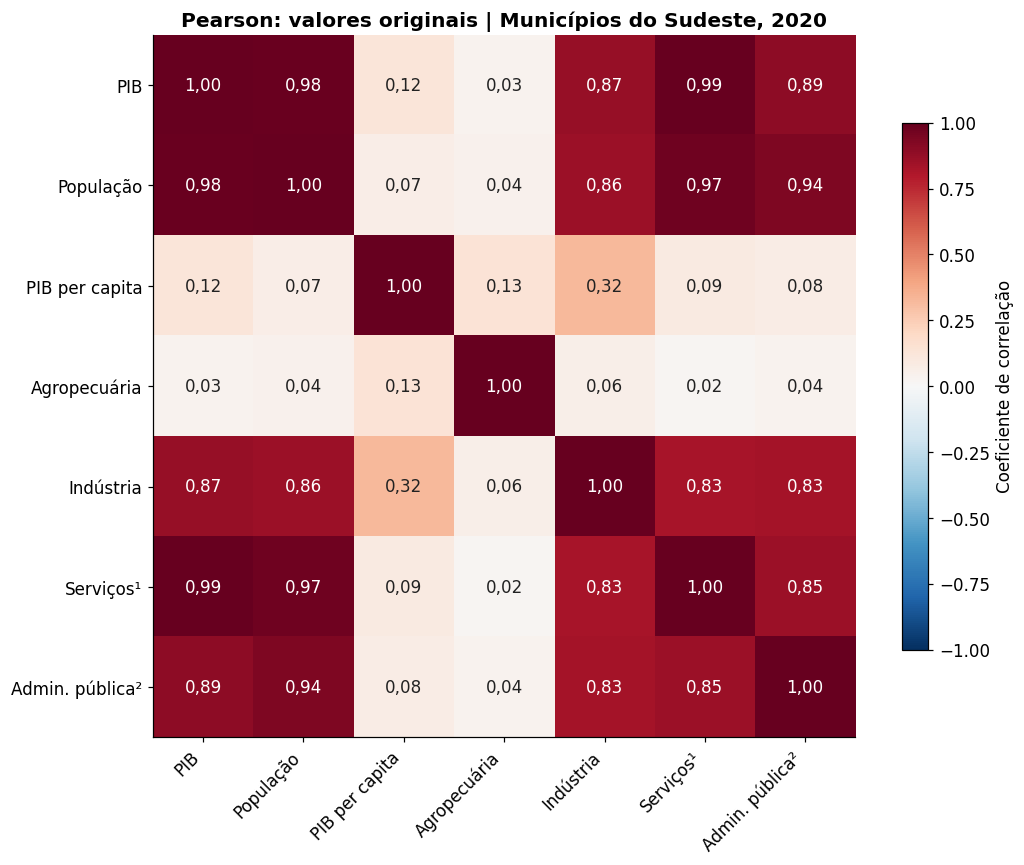

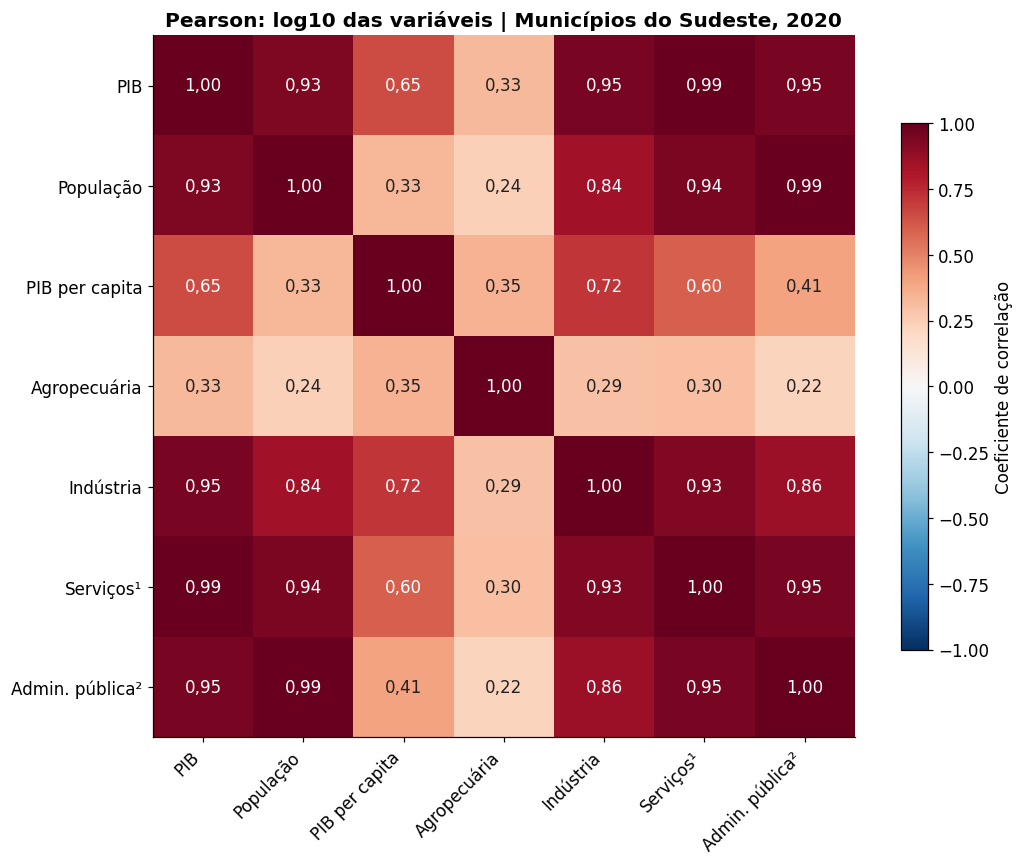

,metrica,pib_populacao,n
0,Pearson original,0.9850,1668
1,Pearson log10,0.9328,1668
2,Spearman,0.9114,1668


**Interpretação:** PIB e população apresentam associação positiva: Pearson = 0,985 nos valores originais, Pearson = 0,933 em log10 e Spearman = 0,911. A associação também aparece na ordenação dos municípios e na escala logarítmica, mas isso não elimina possíveis fatores de confusão nem prova que aumentar a população cause aumento do PIB. A análise é descritiva de 2020, sem teste causal.

In [5]:
peter_dados=peter_df[peter_vars].astype(float)
peter_corr=peter_dados.corr(method='pearson')
peter_mask_log=(peter_dados>0).all(axis=1)
peter_corr_log=np.log10(peter_dados.loc[peter_mask_log]).corr()
peter_csv(peter_corr,'correlacao_pearson_original')
peter_csv(peter_corr_log,'correlacao_pearson_log10')
print('N Pearson original:',len(peter_dados),'N log10:',int(peter_mask_log.sum()),
      'Excluídos do log10:',int((~peter_mask_log).sum()))
for matriz, titulo, nome in [(peter_corr,'Pearson: valores originais','correlacao_original'),
                             (peter_corr_log,'Pearson: log10 das variáveis','correlacao_log10')]:
    fig, ax=plt.subplots(figsize=(10,8))
    im=ax.imshow(matriz,vmin=-1,vmax=1,cmap='RdBu_r')
    ax.set_xticks(range(7),peter_labels,rotation=45,ha='right');ax.set_yticks(range(7),peter_labels)
    for i in range(7):
        for j in range(7):
            v=matriz.iloc[i,j]
            ax.text(j,i,peter_br(v,2),ha='center',va='center',color='white' if abs(v)>.6 else '#222222')
    ax.set_title(titulo+' | Municípios do Sudeste, 2020')
    fig.colorbar(im,ax=ax,shrink=.75,label='Coeficiente de correlação')
    fig.tight_layout();peter_salvar(fig,nome)
peter_r=float(peter_corr.loc['pib_total_reais','populacao'])
peter_rlog=float(np.log10(peter_dados[['pib_total_reais','populacao']]).corr().iloc[0,1])
peter_rho=float(peter_dados[['pib_total_reais','populacao']].corr(method='spearman').iloc[0,1])
peter_relacoes=pd.DataFrame({'metrica':['Pearson original','Pearson log10','Spearman'],
                           'pib_populacao':[peter_r,peter_rlog,peter_rho],'n':[len(peter_df)]*3})
peter_csv(peter_relacoes,'associacao_pib_populacao')
display(peter_relacoes.round(4))
display(Markdown(f"""**Interpretação:** PIB e população apresentam associação positiva: Pearson = {peter_br(peter_r,3)} nos valores originais, Pearson = {peter_br(peter_rlog,3)} em log10 e Spearman = {peter_br(peter_rho,3)}. A associação também aparece na ordenação dos municípios e na escala logarítmica, mas isso não elimina possíveis fatores de confusão nem prova que aumentar a população cause aumento do PIB. A análise é descritiva de 2020, sem teste causal."""))

## 6. Dispersão entre PIB e população
Cada ponto representa um município, com cor identificando o estado. Ambos os eixos usam escala logarítmica de base 10: distâncias iguais representam multiplicações iguais. A escala permite visualizar municípios pequenos e grandes no mesmo gráfico. Municípios acima de outros com população semelhante possuem maior PIB por habitante.

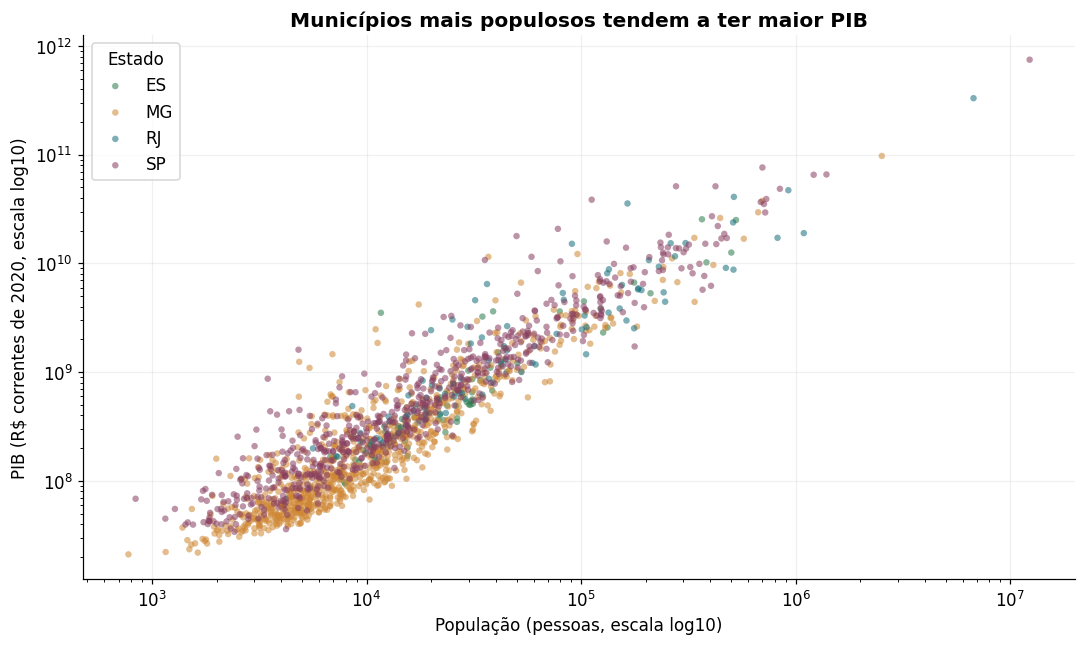

**Interpretação:** a nuvem apresenta tendência crescente, com dispersão vertical. O tamanho populacional se associa ao volume produzido, mas municípios de população semelhante podem apresentar PIBs distintos. O gráfico não identifica causas, renda disponível ou distribuição interna de renda.

In [6]:
fig, ax=plt.subplots(figsize=(10,6))
for uf, cor in zip(peter_ufs,peter_cores):
    parte=peter_df.loc[peter_df.uf==uf]
    ax.scatter(parte.populacao,parte.pib_total_reais,s=18,alpha=.55,color=cor,label=uf,edgecolors='none')
ax.set_xscale('log');ax.set_yscale('log')
ax.set_xlabel('População (pessoas, escala log10)')
ax.set_ylabel('PIB (R$ correntes de 2020, escala log10)')
ax.set_title('Municípios mais populosos tendem a ter maior PIB')
ax.legend(title='Estado');ax.grid(True,which='major',alpha=.18)
fig.tight_layout();peter_salvar(fig,'dispersao_pib_populacao')
display(Markdown('**Interpretação:** a nuvem apresenta tendência crescente, com dispersão vertical. O tamanho populacional se associa ao volume produzido, mas municípios de população semelhante podem apresentar PIBs distintos. O gráfico não identifica causas, renda disponível ou distribuição interna de renda.'))

## 7. Conclusões parciais e limites
As comparações evidenciam concentração territorial do PIB e diferenças de produção por habitante. A composição setorial varia entre estados, embora Serviços¹ tenha o maior peso em todos eles. A população se associa positivamente ao PIB municipal, sem explicar sozinha suas diferenças.

Esses resultados contribuem para a pergunta-guia com evidências de disparidades **dentro do Sudeste**. Não quantificam a desigualdade de renda entre pessoas e não substituem uma comparação entre todas as regiões brasileiras. Um único ano não permite inferir evolução, tendência histórica ou efeitos causais da pandemia.

## 8. Reprodutibilidade e integração
Executar todas as células em ordem, com as dependências gerais do repositório e `scripts/peter/requirements.txt`. Esta seção lê o Parquet sem alterá-lo. Figuras usam prefixo `peter_` em `outputs/figures/`. Tabelas e roteiro ficam em `outputs/peter/`. O manifesto do grupo já aponta para `notebooks/contribuicoes/03_peter.ipynb`.

Os nomes principais têm prefixo `peter_` para reduzir conflitos na integração. A revisão visual das figuras dos colegas e a execução do notebook completo devem ocorrer após a entrega de todas as seções.

In [7]:
# Exporta os mesmos resultados para os slides, sem recalcular números manualmente.
peter_resultados={
 'ano':2020,'n':len(peter_df),'sha256_base':hashlib.sha256(peter_base.read_bytes()).hexdigest(),
 'estados':peter_estados.reset_index().to_dict(orient='records'),
 'setores':peter_setorial.reset_index().to_dict(orient='records'),
 'composicao':peter_comp.reset_index().to_dict(orient='records'),
 'labels':peter_labels,'corr':peter_corr.to_numpy().tolist(),
 'r':peter_r,'r_log':peter_rlog,'rho':peter_rho,
 'n_log':int(peter_mask_log.sum()),'residuo_max_reais':float(peter_residuo.abs().max()),
 'dispersao':{uf: {'x':np.log10(peter_df.loc[peter_df.uf==uf,'populacao']).tolist(),
                   'y':np.log10(peter_df.loc[peter_df.uf==uf,'pib_total_reais']).tolist()} for uf in peter_ufs}}
(peter_out/'resultados.json').write_text(json.dumps(peter_resultados,ensure_ascii=False,indent=2),encoding='utf-8')
print('Tabelas, figuras e resultados exportados.')

Tabelas, figuras e resultados exportados.
